### Middleware
Middleware provides a way to more tightly control what happens inside the agent. Middleware is useful for the following:

Tracking agent behavior with logging, analytics, and debugging.
Transforming prompts, tool selection, and output formatting.
Adding retries, fallbacks, and early termination logic.
Applying rate limits, guardrails, and PII detection.

In [1]:
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_google_genai import ChatGoogleGenerativeAI
import os

load_dotenv()

model = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite-preview",
    google_api_key=os.getenv("GOOGLE_API_KEY")
)
model

ChatGoogleGenerativeAI(metadata={'lc_versions': {'langchain-core': '1.6.2', 'langchain': '1.4.0', 'langchain-google-genai': '4.4.0'}}, profile={'name': 'Gemini 3.1 Flash Lite Preview', 'status': 'deprecated', 'release_date': '2026-03-03', 'last_updated': '2026-03-03', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True, 'reasoning_effort_levels': ['minimal', 'low', 'medium', 'high'], 'reasoning_effort_default': 'minimal'}, google_api_key=SecretStr('**********'), model='gemini-3.1-flash-lite-preview', temperature=None, client=<google.genai.client.Client object at 0x0000023CDB

### Summarization MiddleWare
Automatically summarize conversation history when approaching token limits, preserving recent messages while compressing older context. Summarization is useful for the following:

Long-running conversations that exceed context windows.
Multi-turn dialogues with extensive history.
Applications where preserving full conversation context matters.

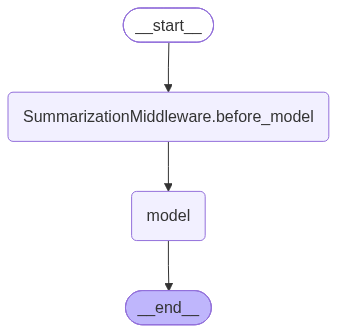

In [9]:
from dotenv import load_dotenv
import os
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage

load_dotenv()

# Gemini model using Google API key
model = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite-preview",
    google_api_key=os.getenv("GOOGLE_API_KEY")
)

agent = create_agent(
    model=model,
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model=model,
            trigger=("messages", 10),
            keep=("messages", 4)
        )
    ]
)
agent

In [10]:
### Run with thread id
config={"configurable":{"thread_id":"test-1"}}

In [11]:
# Alternative test data
questions = [
    "What is 2+2?",
    "What is 10*5?",
    "What is 100/4?",
    "What is 15-7?",
    "What is 3*3?",
    "What is 4*4?",
]

for q in questions:
    response=agent.invoke({"messages":[HumanMessage(content=q)]},config)
    print(f"Messages: {response}")
    print(f"Messages: {len(response['messages'])}")

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


Messages: {'messages': [HumanMessage(content='What is 2+2?', additional_kwargs={}, response_metadata={}, id='49136fab-dcd6-463f-b586-2b967f538a30'), AIMessage(content=[{'type': 'text', 'text': '2 + 2 = 4', 'extras': {'signature': 'EnEKbwERTTIPOklMzP+IdTJiA6GHhpspDU9yP2+vSmdHtJtZB64AZ3E39CvGsu4+hK40POLwfGkyv+zTLmlIe8iP/QvLbV4OuB1TM74YP5/L8skVe2h2DBnCwJUKce7ZVZ99CmbbZskXAi/u/3/btKmEDw=='}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0810b-600e-7a90-a510-cc640d5ec646-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 7, 'total_tokens': 15, 'input_token_details': {'cache_read': 0}})]}
Messages: 2
Messages: {'messages': [HumanMessage(content='What is 2+2?', additional_kwargs={}, response_metadata={}, id='49136fab-dcd6-463f-b586-2b967f538a30'), AIMessage(content=[{'type': 'text', 'text': '2 + 2 = 4', 'extras': {'sign